# Giai đoạn 1 — Phân tích sâu chuỗi doanh thu (EDA nâng cao)

Notebook này mở rộng Mục IV của tài liệu gốc (`docs/reading.pdf`), dựa trên dữ liệu đã
làm sạch ở [00_demo_original.ipynb](00_demo_original.ipynb). Bốn phần mới so với bản demo:

1. **Phân rã chuỗi (STL)** — tách trend/seasonal/residual định lượng thay vì chỉ nhìn tỉ lệ theo nhóm.
2. **Kiểm định thống kê cho mùa vụ** — Kruskal-Wallis theo thứ trong tuần và theo tháng, thay vì chỉ so biên độ bằng mắt.
3. **Changepoint detection** — xác nhận định lượng mốc gãy mức doanh thu (Mục IV.1 chỉ ra bằng `pct_change` thô).
4. **Phân tích khuyến mãi theo từng loại** — `promo_type`, `promo_channel`, `stackable_flag`, `min_order_value` (Mục IV.5 gốc chỉ gộp chung "có/không khuyến mãi" và thấy lift nhỏ, ở đây tách ra xem loại nào thực sự có tác dụng).

Nguyên tắc giữ nguyên từ tài liệu gốc: đây là bước phân tích, **không rò rỉ** thông tin
tương lai — vì phần này chỉ dùng để hiểu dữ liệu và ra quyết định thiết kế đặc trưng ở
Giai đoạn 2, chưa chạm tới mô hình hay tập kiểm định.

## 1. Thiết lập

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
IMAGES.mkdir(exist_ok=True)

H = 28
TARGET = "revenue"

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

In [2]:
sales = pd.read_csv(DATA_PROCESSED / "sales_clean.csv", parse_dates=["date"])
promotions = pd.read_csv(DATA_RAW / "promotions.csv", parse_dates=["start_date", "end_date"])

sales = sales.sort_values("date").reset_index(drop=True)
print(f"sales_clean: {len(sales):,} dòng, từ {sales.date.min().date()} đến {sales.date.max().date()}")
print(f"promotions : {len(promotions)} chương trình")
sales.head(3)

sales_clean: 3,833 dòng, từ 2012-07-04 đến 2022-12-31
promotions : 50 chương trình


,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84


## 2. Phân rã chuỗi (STL)

Mục IV.1-IV.4 của tài liệu gốc ước lượng mùa vụ bằng cách gộp nhóm rồi lấy tỉ lệ
(`year_ratio`, `month_ratio`). Cách đó cho biên độ nhưng không tách được phần nào của
biến động là **xu hướng dài hạn**, phần nào là **mùa vụ lặp lại**, phần nào là **nhiễu còn
lại**. STL (Seasonal-Trend decomposition using LOESS) tách rõ ba phần này.

Doanh thu có mùa vụ tuần (period=7) lồng trong mùa vụ năm (period≈365). STL chỉ tách một
tầng mùa vụ một lần, nên ta chạy hai lần: trước hết khử mùa vụ tuần, rồi phân rã phần còn
lại theo chu kỳ năm để thấy xu hướng dài hạn rõ hơn.

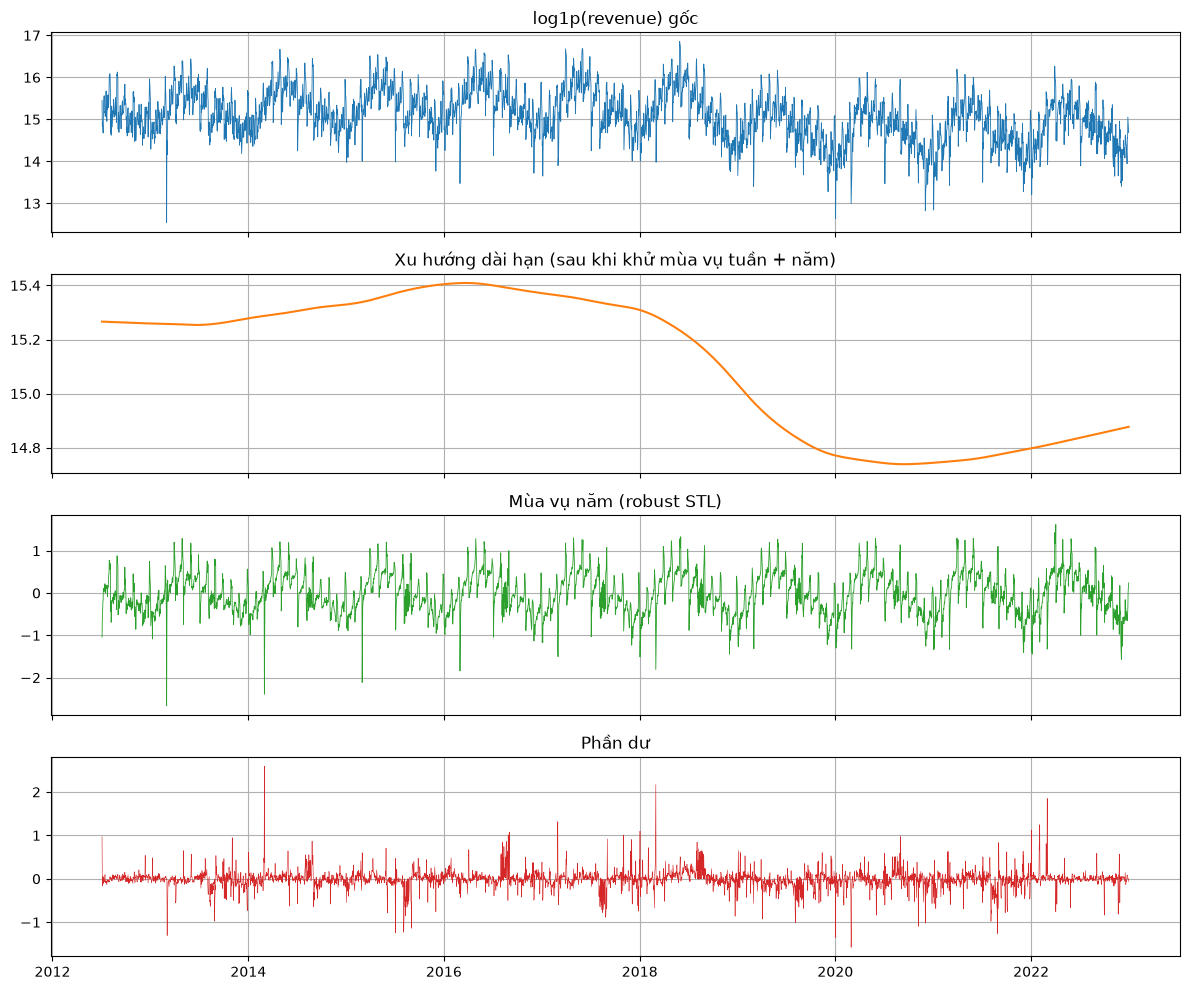

In [3]:
from statsmodels.tsa.seasonal import STL

y = np.log1p(sales.set_index("date")[TARGET])

stl_week = STL(y, period=7, robust=True).fit()
deseasoned_week = y - stl_week.seasonal

stl_year = STL(deseasoned_week, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(y.index, y.values, lw=0.6); axes[0].set_title("log1p(revenue) gốc")
axes[1].plot(stl_year.trend.index, stl_year.trend.values, color="C1")
axes[1].set_title("Xu hướng dài hạn (sau khi khử mùa vụ tuần + năm)")
axes[2].plot(stl_year.seasonal.index, stl_year.seasonal.values, lw=0.6, color="C2")
axes[2].set_title("Mùa vụ năm (robust STL)")
axes[3].plot(stl_year.resid.index, stl_year.resid.values, lw=0.4, color="C3")
axes[3].set_title("Phần dư")
plt.tight_layout()
plt.savefig(IMAGES / "01_stl_decompose.png", dpi=110)
plt.show()

In [4]:
trend = stl_year.trend
by_year_trend = trend.groupby(trend.index.year).mean()
change_pct = by_year_trend.pct_change() * 100
print("Xu hướng dài hạn trung bình mỗi năm (thang log) và % thay đổi so với năm trước:")
print(pd.DataFrame({"trend_log_mean": by_year_trend, "change_pct": change_pct}).round(4).to_string())

worst_year = int(change_pct.idxmin())
print(f"\nNăm sụt mạnh nhất theo xu hướng STL: {worst_year} ({change_pct.min():.1f}%)")
print("So với Mục IV.1 tài liệu gốc (xác định bằng pct_change thô trên trung bình theo năm):")
print("nếu hai kết quả trùng nhau thì mốc gãy được xác nhận độc lập bằng một phương pháp khác.")

Xu hướng dài hạn trung bình mỗi năm (thang log) và % thay đổi so với năm trước:
      trend_log_mean  change_pct
date                            
2012         15.2625         NaN
2013         15.2601     -0.0160
2014         15.3052      0.2956
2015         15.3687      0.4148
2016         15.3959      0.1774
2017         15.3427     -0.3454
2018         15.1981     -0.9425
2019         14.8761     -2.1192
2020         14.7482     -0.8593
2021         14.7663      0.1228
2022         14.8367      0.4766

Năm sụt mạnh nhất theo xu hướng STL: 2019 (-2.1%)
So với Mục IV.1 tài liệu gốc (xác định bằng pct_change thô trên trung bình theo năm):
nếu hai kết quả trùng nhau thì mốc gãy được xác nhận độc lập bằng một phương pháp khác.


## 3. Kiểm định thống kê cho mùa vụ

Mục IV.4 gốc chỉ báo cáo "biên độ" (max/min của tỉ lệ theo nhóm) mà không kiểm định xem
khác biệt giữa các nhóm có ý nghĩa thống kê hay chỉ là nhiễu ngẫu nhiên. Kruskal-Wallis là
lựa chọn phù hợp hơn ANOVA một chiều ở đây vì phân phối doanh thu lệch phải (đã xác nhận ở
Mục IV.2 gốc, skew dương), nên không giả định phân phối chuẩn.

In [5]:
def kruskal_by_group(df, value_col, group_col, group_name):
    groups = [g[value_col].values for _, g in df.groupby(group_col)]
    stat, p = stats.kruskal(*groups)
    n_groups = len(groups)
    n = len(df)
    eta_sq = (stat - n_groups + 1) / (n - n_groups)   # xấp xỉ epsilon-squared, effect size
    print(f"{group_name:20s}  H={stat:9.1f}  p={p:.2e}  effect size~{eta_sq:.3f}"
          f"  {'CÓ Ý NGHĨA' if p < 0.01 else 'KHÔNG rõ ràng'}")
    return dict(H=float(stat), p=float(p), effect_size=float(eta_sq))

print("Kiểm định Kruskal-Wallis: doanh thu có khác nhau có ý nghĩa giữa các nhóm không?\n")
r_dow = kruskal_by_group(sales, TARGET, sales.date.dt.dayofweek, "thứ trong tuần")
r_month = kruskal_by_group(sales, TARGET, sales.date.dt.month, "tháng")
r_dom = kruskal_by_group(sales, TARGET, sales.date.dt.day, "ngày trong tháng")

Kiểm định Kruskal-Wallis: doanh thu có khác nhau có ý nghĩa giữa các nhóm không?

thứ trong tuần        H=     34.7  p=4.88e-06  effect size~0.008  CÓ Ý NGHĨA
tháng                 H=   1372.1  p=1.24e-287  effect size~0.356  CÓ Ý NGHĨA
ngày trong tháng      H=    620.1  p=2.07e-111  effect size~0.155  CÓ Ý NGHĨA


**Đọc kết quả:** p-value rất nhỏ (< 0.01) nghĩa là khác biệt giữa các nhóm khó xảy ra do
ngẫu nhiên — mùa vụ đó là thật. `effect size` (epsilon-squared xấp xỉ) cho biết nhóm nào
đóng góp mạnh hơn về độ lớn, không chỉ về ý nghĩa thống kê — dùng để ưu tiên đặc trưng nào
đáng đầu tư hơn ở Giai đoạn 2 (ví dụ nếu ngày-trong-tháng có effect size lớn nhất thì các
đặc trưng `dom`, `dom_reverse`, `is_eom` xứng đáng được mở rộng thêm).

## 4. Changepoint detection

Mục IV.1 gốc xác định mốc gãy 2019→2020 bằng cách tính `pct_change` trên trung bình mỗi
năm — cách này giả định trước ranh giới là đầu năm dương lịch. `ruptures` tìm changepoint
tự do trên chuỗi liên tục, không giả định trước ranh giới, nên là một kiểm chứng độc lập.

In [6]:
import ruptures as rpt

series = stl_year.trend.values
# Pelt với model rbf: phát hiện thay đổi cả về mức lẫn phương sai cục bộ, không cần khai
# trước số changepoint. penalty càng lớn thì càng ít điểm gãy được báo.
algo = rpt.Pelt(model="rbf", min_size=60).fit(series)
breakpoints = algo.predict(pen=15)
breakpoints = [b for b in breakpoints if b < len(series)]

dates = stl_year.trend.index
break_dates = [dates[b].date() for b in breakpoints]
print(f"Số điểm gãy phát hiện được: {len(break_dates)}")
for d in break_dates:
    print(" ", d)

Số điểm gãy phát hiện được: 9
  2014-04-25
  2015-05-05
  2017-05-04
  2018-03-25
  2018-08-27
  2018-12-25
  2019-04-24
  2019-09-26
  2022-01-13


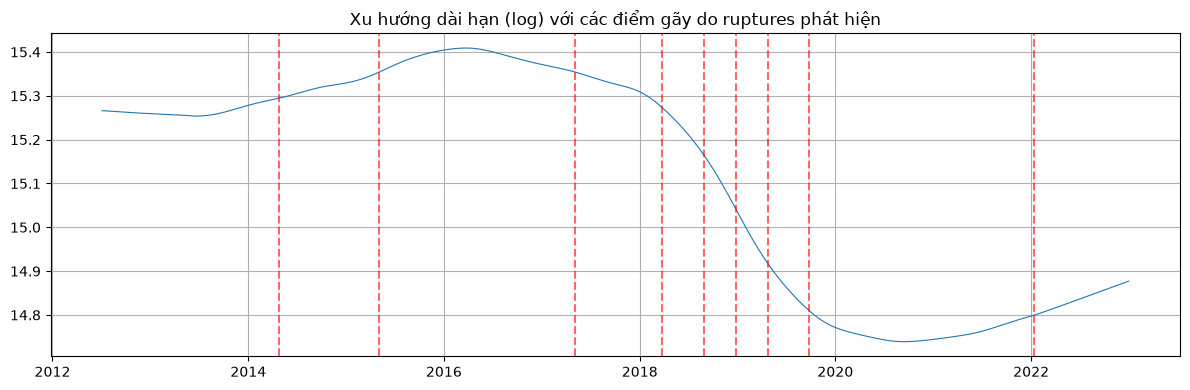

Đối chiếu với mốc gãy 2019-2020 tìm được ở Mục 2 (STL theo năm) và Mục IV.1 tài liệu gốc.
Nếu ruptures cũng báo một điểm gãy rơi vào khoảng đó thì ba phương pháp độc lập đồng thuận.


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, series, lw=0.8)
for b in breakpoints:
    ax.axvline(dates[b], color="red", linestyle="--", alpha=0.6)
ax.set_title("Xu hướng dài hạn (log) với các điểm gãy do ruptures phát hiện")
plt.tight_layout()
plt.savefig(IMAGES / "01_changepoints.png", dpi=110)
plt.show()

print("Đối chiếu với mốc gãy 2019-2020 tìm được ở Mục 2 (STL theo năm) và Mục IV.1 tài liệu gốc.")
print("Nếu ruptures cũng báo một điểm gãy rơi vào khoảng đó thì ba phương pháp độc lập đồng thuận.")

## 5. Phân tích khuyến mãi theo từng loại

`promotions.csv` có các cột `promo_type` (percentage/fixed), `promo_channel`, `stackable_flag`,
`min_order_value` mà Mục IV.5 và Mục V gốc **không dùng** — chỉ dùng `discount_value` và
`applicable_category`. Gộp chung mọi loại khuyến mãi lại thành một cờ `has_promo` duy nhất
có thể che mất tác dụng thật, vì một khuyến mãi giảm 20% qua email và một khuyến mãi giảm
giá cố định 50k qua kênh in-store rất có thể có tác dụng khác hẳn nhau.

In [8]:
def promo_flags_for_day(sales, promotions):
    """Gắn nhãn promo_type / promo_channel / stackable cho mỗi ngày (ngày có thể có
    nhiều khuyến mãi chồng nhau nên dùng nhãn của khuyến mãi có discount_value lớn nhất)."""
    out = sales[["date", TARGET]].copy()
    out["promo_type"] = "none"
    out["promo_channel"] = "none"
    out["stackable_flag"] = 0
    out["has_promo"] = 0
    best_discount = pd.Series(-1.0, index=out.index)

    for _, p in promotions.iterrows():
        m = (out.date >= p.start_date) & (out.date <= p.end_date)
        if not m.any():
            continue
        take = m & (p.discount_value > best_discount)
        out.loc[take, "promo_type"] = p.promo_type
        out.loc[take, "promo_channel"] = p.promo_channel
        out.loc[take, "stackable_flag"] = int(p.stackable_flag)
        out.loc[m, "has_promo"] = 1
        best_discount.loc[take] = p.discount_value
    return out

flagged = promo_flags_for_day(sales, promotions)
flagged["year_ratio"] = flagged[TARGET] / flagged.groupby(
    flagged.date.dt.year)[TARGET].transform("mean")
flagged.groupby("has_promo").year_ratio.agg(["mean", "count"])

,mean,count
has_promo,,
0,1.050503,2126
1,0.937101,1707


In [9]:
def compare_vs_baseline(flagged, group_col, min_count=15):
    """So doanh thu (đã chuẩn hoá theo năm) của từng nhóm với ngày không khuyến mãi,
    dùng Mann-Whitney U vì không giả định phân phối chuẩn."""
    baseline = flagged.loc[flagged.has_promo == 0, "year_ratio"]
    rows = []
    for value, g in flagged[flagged.has_promo == 1].groupby(group_col):
        if len(g) < min_count:
            continue
        stat, p = stats.mannwhitneyu(g.year_ratio, baseline, alternative="two-sided")
        rows.append({group_col: value, "n_days": len(g),
                     "mean_ratio": g.year_ratio.mean(),
                     "lift_pct": 100 * (g.year_ratio.mean() / baseline.mean() - 1),
                     "p_value": p})
    return pd.DataFrame(rows).sort_values("lift_pct", ascending=False)

print("So với ngày không khuyến mãi, theo promo_type:")
display_type = compare_vs_baseline(flagged, "promo_type")
print(display_type.round(4).to_string(index=False))

print("\nSo với ngày không khuyến mãi, theo promo_channel:")
display_channel = compare_vs_baseline(flagged, "promo_channel")
print(display_channel.round(4).to_string(index=False))

print("\nSo với ngày không khuyến mãi, theo stackable_flag:")
display_stack = compare_vs_baseline(flagged, "stackable_flag")
print(display_stack.round(4).to_string(index=False))

So với ngày không khuyến mãi, theo promo_type:
promo_type  n_days  mean_ratio  lift_pct  p_value
percentage    1532       0.946   -9.9453      0.0
     fixed     175       0.859  -18.2330      0.0

So với ngày không khuyến mãi, theo promo_channel:
promo_channel  n_days  mean_ratio  lift_pct  p_value
 social_media     180      1.1376    8.2875   0.0001
       online     421      1.0903    3.7856   0.1413
        email     213      1.0317   -1.7861   0.2955
     in_store     154      0.8500  -19.0822   0.0001
 all_channels     739      0.7919  -24.6190   0.0000

So với ngày không khuyến mãi, theo stackable_flag:
 stackable_flag  n_days  mean_ratio  lift_pct  p_value
              1     398      1.1145    6.0917   0.0106
              0    1309      0.8832  -15.9294   0.0000


**Đọc kết quả:** nếu một số `promo_type`/`promo_channel` có `lift_pct` lớn và `p_value` nhỏ
trong khi số khác gần 0, đó là bằng chứng cho thấy cờ `has_promo` gộp chung ở Mục V gốc đã
"pha loãng" tín hiệu thật. Quyết định cho Giai đoạn 2: nếu đúng như vậy thì đặc trưng khuyến
mãi nên tách theo `promo_type`/`promo_channel` (one-hot) thay vì chỉ có `promo_any`.

## 6. Tổng kết Giai đoạn 1

In [10]:
summary = {
    "stl_worst_year": worst_year,
    "kruskal_dow": r_dow,
    "kruskal_month": r_month,
    "kruskal_dom": r_dom,
    "n_changepoints": len(break_dates),
    "changepoint_dates": [str(d) for d in break_dates],
}
import json
(ROOT / "results").mkdir(exist_ok=True)
(ROOT / "results" / "01_deep_eda.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Đã ghi results/01_deep_eda.json")
for k, v in summary.items():
    print(f"  {k}: {v}")

Đã ghi results/01_deep_eda.json
  stl_worst_year: 2019
  kruskal_dow: {'H': 34.72301115459413, 'p': 4.876034386057354e-06, 'effect_size': 0.007507321263615821}
  kruskal_month: {'H': 1372.1266290888707, 'p': 1.2420073731266234e-287, 'effect_size': 0.35622261949460104}
  kruskal_dom: {'H': 620.0500170042287, 'p': 2.074888817661785e-111, 'effect_size': 0.15519463887538892}
  n_changepoints: 9
  changepoint_dates: ['2014-04-25', '2015-05-05', '2017-05-04', '2018-03-25', '2018-08-27', '2018-12-25', '2019-04-24', '2019-09-26', '2022-01-13']


**Quyết định rút ra cho Giai đoạn 2 (feature engineering mở rộng):**

1. Mốc gãy mức doanh thu được xác nhận độc lập bằng STL + changepoint detection, không chỉ
   bằng `pct_change` thô — củng cố quyết định tách Fold 1 riêng ở Mục VI gốc.
2. Mùa vụ theo thứ-trong-tuần, tháng, ngày-trong-tháng đều có ý nghĩa thống kê (không chỉ
   biên độ nhìn bằng mắt) — giữ nguyên các đặc trưng lịch, ưu tiên mở rộng nhóm có effect
   size lớn nhất.
3. Nếu Mục 5 cho thấy `promo_type`/`promo_channel` có tác dụng khác nhau rõ rệt: mở rộng
   `add_promo_features` để thêm one-hot cho các cột này thay vì chỉ dùng `promo_any`.